# Кластеризация и классификация фильмов (с оптимизацией производительности)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import warnings
import pickle
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import NMF

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pymorphy3

# Библиотеки для многопоточности и кэширования
from functools import lru_cache
from joblib import Parallel, delayed

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

plt.rcParams["figure.figsize"] = (14, 6)


## Загрузка и предобработка данных


In [3]:
df = pd.read_csv('merged_films.csv')
print("Films shape:", df.shape)
display(df.head(3))


Films shape: (254, 6)


,name,country,category,year,rating,description
0,1+1,Франция,драма,2011,8.859,"Пострадав в результате несчастного случая, бог..."
1,12 лет рабства,Великобритания,драма,2013,7.948,США до Гражданской войны. Семьянин Соломон Нор...
2,12 разгневанных мужчин,США,драма,1956,8.530,"Юношу обвиняют в убийстве собственного отца, е..."


### Определение функций очистки, кэширования лемматизации и многопоточной обработки

- **`@lru_cache`**: сохраняет результаты разбора слов в памяти. Если слово повторяется, парсер `pymorphy3` не вызывается заново, что экономит 90% процессорного времени.
- **`Parallel(n_jobs=-1, backend="threading")`**: распределяет задачи обработки текстов параллельно по всем доступным вычислительным потокам, обходя ограничения Windows на сериализацию процессов.


In [4]:
russian_stopwords = stopwords.words("russian") 
russian_stopwords.extend([
    'т.д.', 'т', 'д', 'это','который','свой','своём','всем','всё','её','оба','ещё','должный',
    "фильм", "кино", "режиссер", "актер", "роль", "герой", "жизнь", "человек"
]) 

def fun_punctuation_text(text):
    text = str(text).lower()
    text = ''.join([ch for ch in text if ch not in string.punctuation])
    text = ''.join([i if not i.isdigit() else '' for i in text])
    text = ''.join([i if i.isalpha() else ' ' for i in text])
    text = re.sub(r'\s+', ' ', text, flags=re.I)
    text = re.sub('[a-z]', '', text, flags=re.I)
    st = '❯\xa0—«»'
    text = ''.join([ch if ch not in st else ' ' for ch in text])
    return text

# Создаем один глобальный экземпляр анализатора
morph = pymorphy3.MorphAnalyzer(lang='ru')

# Декоратор кэширует лемматизированную форму для каждого уникального слова
@lru_cache(maxsize=100000)
def lemmatize_word(word):
    return morph.parse(word)[0].normal_form

def fun_lemmatizing_text(text):
    tokens = word_tokenize(text)
    res = list()
    for word in tokens:
        res.append(lemmatize_word(word))  # Обращение к быстрому кэшу
    text = " ".join(res)
    return text

def fun_tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    text = " ".join(tokens)
    return text

# Подготовка текстового корпуса
df['corpus'] = (
    df['name'].fillna('') + ' ' +
    df['country'].fillna('') + ' ' +
    df['category'].fillna('') + ' ' +
    df['description'].fillna('')
)

print("Шаг 1: Очистка текста от пунктуации...")
df['clean_text'] = df['corpus'].apply(fun_punctuation_text)

# Лемматизация через joblib Parallel (использование всех вычислительных потоков)
print("Шаг 2: Многопоточная лемматизация с кэшированием слов...")
df['lemm_text'] = Parallel(n_jobs=-1, backend="threading")(
    delayed(fun_lemmatizing_text)(text) for text in df['clean_text']
)

print("Шаг 3: Токенизация и фильтрация стоп-слов...")
df['tokenize_text'] = df['lemm_text'].apply(fun_tokenize)

print("Предобработка завершена!")
display(df[['name', 'tokenize_text']].head(3))


Шаг 1: Очистка текста от пунктуации...
Шаг 2: Многопоточная лемматизация с кэшированием слов...
Шаг 3: Токенизация и фильтрация стоп-слов...
Предобработка завершена!


,name,tokenize_text
0,1+1,франция драма пострадать результат несчастный ...
1,12 лет рабства,год рабство великобритания драма сша гражданск...
2,12 разгневанных мужчин,разгневать мужчина сша драма юноша обвинять уб...


## Векторизация текста


In [5]:
vectorizer = TfidfVectorizer(
    max_features=5000,  
    min_df=2,           
    max_df=0.95,        
    ngram_range=(1, 3),  
    stop_words=russian_stopwords      
)

tfidf_matrix = vectorizer.fit_transform(df['tokenize_text'])
print(f"Размер TF-IDF матрицы: {tfidf_matrix.shape}")
print(f"Количество признаков: {len(vectorizer.get_feature_names_out())}")


Размер TF-IDF матрицы: (254, 1835)
Количество признаков: 1835


## Выделение тематик (классов) с помощью NMF


In [6]:
# Обучаем NMF для получения 5 тем
nmf_model = NMF(n_components=5, random_state=0, init="nndsvda")
X_topics_nmf = nmf_model.fit_transform(tfidf_matrix)

# Присваиваем каждому фильму доминирующую тему
df['topic_nmf'] = np.argmax(X_topics_nmf, axis=1)

print("Вывод топ слов для каждой темы:")
for i, topic in enumerate(nmf_model.components_):
    words = [vectorizer.get_feature_names_out()[idx] for idx in topic.argsort()[:-11:-1]]
    print(f"Тема {i}: {', '.join(words)}")

print("\nРаспределение фильмов по темам:")
print(df['topic_nmf'].value_counts())


Вывод топ слов для каждой темы:
Тема 0: драма, сша, сша драма, год, друг, мочь, однажды, дом, стать, день
Тема 1: мировой война, второй мировой война, второй мировой, мировой, война, второй, биография, время второй мировой, время второй, сша биография
Тема 2: гарри, гарри поттер, поттер, хогвартс, великобритания фэнтези, школа, великобритания, фэнтези, волшебник, великобритания фэнтези гарри
Тема 3: фантастика, сша фантастика, земля, будущее, сша, человечество, путешествие, кольцо, чёрный, планета
Тема 4: шерлок холмс, шерлок, холмс, доктор ватсон, ватсон, доктор, схватка, шерлок холмс доктор, холмс доктор, холмс доктор ватсон

Распределение фильмов по темам:
topic_nmf
0    156
3     63
1     20
4      8
2      7
Name: count, dtype: int64


## Определение оптимального количества кластеров (K-Means)


Расчет метрик для разных K...
  K=2: WCSS=245.66, Silhouette=0.0036
  K=3: WCSS=244.45, Silhouette=0.0025
  K=4: WCSS=242.69, Silhouette=0.0029
  K=5: WCSS=241.38, Silhouette=0.0031
  K=6: WCSS=240.20, Silhouette=0.0028
  K=7: WCSS=238.88, Silhouette=0.0031
  K=8: WCSS=237.23, Silhouette=0.0036
  K=9: WCSS=235.97, Silhouette=0.0033
  K=10: WCSS=233.77, Silhouette=0.0056


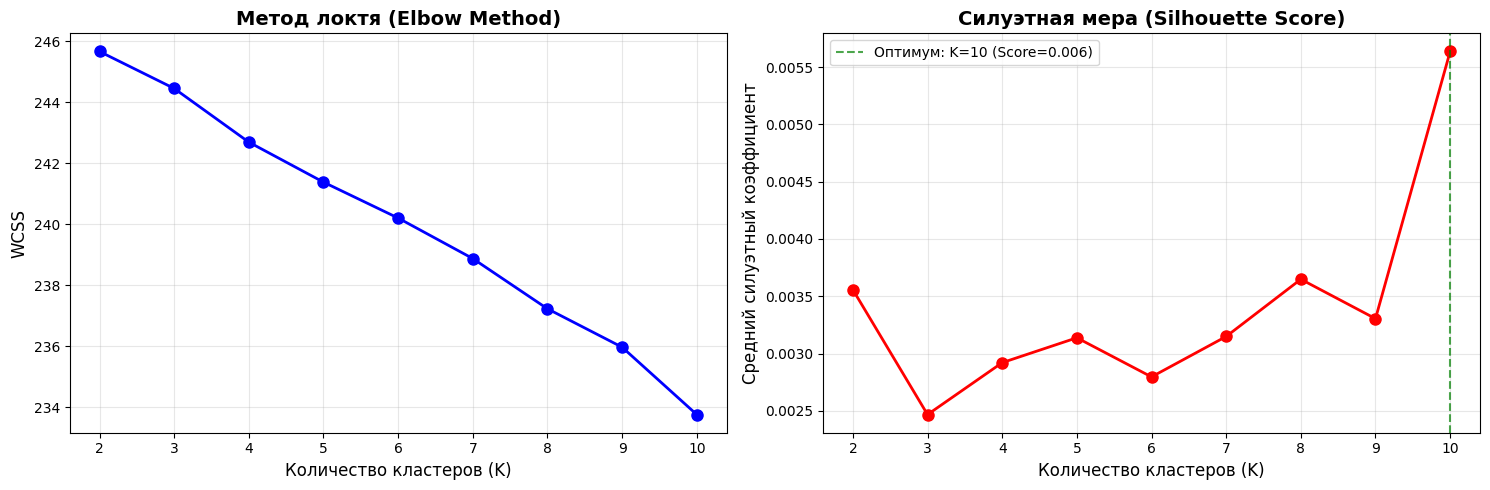

Оптимальное количество кластеров по силуэту: 10


In [7]:
wcss = []
silhouette_scores = []
K_range = range(2, 11)

print("Расчет метрик для разных K...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(tfidf_matrix)
    wcss.append(kmeans.inertia_)
    
    silhouette_avg = silhouette_score(tfidf_matrix, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"  K={k}: WCSS={kmeans.inertia_:.2f}, Silhouette={silhouette_avg:.4f}")

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Метод локтя
ax1.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
ax1.set_title('Метод локтя (Elbow Method)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Количество кластеров (K)', fontsize=12)
ax1.set_ylabel('WCSS', fontsize=12)
ax1.grid(True, alpha=0.3)

# Силуэтная мера
ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_title('Силуэтная мера (Silhouette Score)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Количество кластеров (K)', fontsize=12)
ax2.set_ylabel('Средний силуэтный коэффициент', fontsize=12)
ax2.grid(True, alpha=0.3)

best_k_silhouette = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
ax2.axvline(x=best_k_silhouette, color='green', linestyle='--', alpha=0.7, 
            label=f'Оптимум: K={best_k_silhouette} (Score={best_score:.3f})')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Оптимальное количество кластеров по силуэту: {best_k_silhouette}")


## Классификация текстов


In [8]:
# Разделение выборки
X_train, X_test, y_train, y_test = train_test_split(
    df['tokenize_text'], 
    df['topic_nmf'], 
    test_size=0.3, 
    random_state=0
)

# Обучаем векторизатор на тренировочной выборке
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)


Train TF-IDF shape: (177, 1298)
Test TF-IDF shape: (77, 1298)


### 1. Логистическая регрессия


In [9]:
model_lr = LogisticRegression()
model_lr.fit(X_train_tfidf, y_train)
y_pred_lr = model_lr.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.63      1.00      0.77        46
           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00         1
           3       1.00      0.22      0.36        18
           4       0.00      0.00      0.00         5

    accuracy                           0.65        77
   macro avg       0.33      0.24      0.23        77
weighted avg       0.61      0.65      0.55        77



### 2. Случайный лес


In [10]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_tfidf, y_train)
y_pred_rf = model_rf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.70      1.00      0.82        46
           1       1.00      0.29      0.44         7
           2       1.00      1.00      1.00         1
           3       1.00      0.44      0.62        18
           4       0.00      0.00      0.00         5

    accuracy                           0.74        77
   macro avg       0.74      0.55      0.58        77
weighted avg       0.75      0.74      0.69        77



### 3. Метод ближайших соседей (KNN)


In [11]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_tfidf, y_train)
y_pred_knn = model_knn.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_knn))


              precision    recall  f1-score   support

           0       0.81      1.00      0.89        46
           1       1.00      0.57      0.73         7
           2       1.00      1.00      1.00         1
           3       0.79      0.61      0.69        18
           4       1.00      0.20      0.33         5

    accuracy                           0.82        77
   macro avg       0.92      0.68      0.73        77
weighted avg       0.83      0.82      0.80        77



## Сохранение лучшей модели и векторизатора


In [12]:
# Сохраняем Random Forest классификатор и векторизатор в pkl
with open('model_rf.pkl', 'wb') as f:
    pickle.dump(model_rf, f)

with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("Модели успешно сохранены в model_rf.pkl и vectorizer.pkl")


Модели успешно сохранены в model_rf.pkl и vectorizer.pkl


## Верификация классификатора на тестовых описаниях


In [13]:
def predict_topic(text):
    text = fun_punctuation_text(text)
    text = fun_lemmatizing_text(text)
    text = fun_tokenize(text)
    text_vectorized = vectorizer.transform([text])
    prediction = model_rf.predict(text_vectorized)
    probabilities = model_rf.predict_proba(text_vectorized)
    return prediction[0], probabilities[0]

t1 = "Один ушлый американец ещё со студенческих лет приторговывал наркотиками, а теперь придумал схему нелегального обогащения с использованием поместий обедневшей английской аристократии и очень неплохо на этом разбогател."
t2 = "21 июня 1941 года. Молодой лейтенант Коля Плужников, получив назначение на постоянное место службы, приезжает в Брест. Переполненные залы ожидания вокзала и толпа увешанных багажом людей."
t3 = "Российский ракетный подводный крейсер специального назначения бесследно исчезает во время секретной миссии в Гренландском море. На его поиски отправляется экипаж под командованием Виктора Воронина."

for i, t in enumerate([t1, t2, t3], 1):
    pred, probs = predict_topic(t)
    print(f"Тест {i}: {t[:100]}...")
    print(f"  Предсказанный класс: {pred}")
    print(f"  Вероятности: {probs.round(3)}")
    print()


Тест 1: Один ушлый американец ещё со студенческих лет приторговывал наркотиками, а теперь придумал схему нел...
  Предсказанный класс: 0
  Вероятности: [0.92 0.02 0.   0.06 0.  ]

Тест 2: 21 июня 1941 года. Молодой лейтенант Коля Плужников, получив назначение на постоянное место службы, ...
  Предсказанный класс: 0
  Вероятности: [0.93 0.01 0.   0.06 0.  ]

Тест 3: Российский ракетный подводный крейсер специального назначения бесследно исчезает во время секретной ...
  Предсказанный класс: 0
  Вероятности: [0.85 0.04 0.01 0.1  0.  ]

